# 02 — Figure 3 | GC Content, CAI, and Phylogenetic Distance Analysis

## Configuration

In [37]:
from pathlib import Path

# --- data directory (populate yourself -- see README's Data section) ---
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- paths ---
GENE_DATA_PATH = DATA_DIR / "gene_fitness_lmm_results.parquet"

# --- analysis parameters ---
CONDITION = "LB_4_salt"


## Load data

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats


df_raw = pd.read_parquet(GENE_DATA_PATH)
print(f"{len(df_raw):,} rows loaded")

100,786 rows loaded


## Data preparation

In [39]:
# --- filter to salt condition genes with a gene call ---
salt_genes = df_raw[df_raw["condition"] == CONDITION].copy()

# --- patristic distances (written by figure1.ipynb to results/) ---
phylogeny = pd.read_csv(RESULTS_DIR / "pioneer_genome_gtdb_phylogeny.tsv", sep="\t")
distance_to_ecoli = phylogeny[["pioneer_genome", "distance_to_ecoli"]]

# NOTE: Sapiens_RBS_Score is already merged into the released gene-fitness table,
# so no separate RBS merge step is needed here (unlike the original internal notebook).
print(salt_genes.shape)
salt_genes.head()


(50393, 63)
(50393, 67)


,pioneer_genome,species_name,gene_id,locus_tag,gene_bioname,gene_biotype,gene_chrom,gene_strand,gene_start,gene_end,...,PFAMs,PFAM_descriptions,gc_content,CAI_rel_to_Ecoli,EFF_CODON_N,RARE_CODON_N,rbs_sequence,Sapiens_RBS_Score,Sapiens_RBS_Score_Var,rbs_GC_content
0,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0001,b0001,thrL,protein_coding,NC_000913.3,+,190,255,...,[PF08254],[Threonine leader peptide],51.52,0.5995,55.29,0.0,CAGAGTACACAACATCC,0.069147,0.002247,8.0
1,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0002,b0002,thrA,protein_coding,NC_000913.3,+,337,2799,...,"[PF00696, PF00742, PF03447, PF22468, PF22468]","[Amino acid kinase family, Homoserine dehydrog...",53.07,0.3525,47.41,14.0,GTAACGAGGTAACAACC,0.131970,0.020933,8.0
2,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0003,b0003,thrB,protein_coding,NC_000913.3,+,2801,3733,...,"[PF00288, PF08544]","[GHMP kinases N terminal domain, GHMP kinases ...",56.27,0.3503,53.13,4.0,GAAGTTAGGAGTCTGAC,0.706415,0.002503,8.0
3,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0004,b0004,thrC,protein_coding,NC_000913.3,+,3734,5020,...,"[PF00291, PF14821]","[Pyridoxal-phosphate dependent enzyme, Threoni...",52.84,0.4024,45.18,5.0,GAGTACTGGAAAACTAA,0.267630,0.004195,6.0
4,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0005,b0005,yaaX,protein_coding,NC_000913.3,+,5234,5530,...,[PF10697],[Protein of unknown function (DUF2502)],53.87,0.3662,56.72,4.0,GATAAAAGGAGTAACCT,0.884806,0.002447,6.0


In [40]:
salt_genes_filt = salt_genes[
    salt_genes["gene_call"].isin(["Hit", "Not Hit"])
].copy()

print(f"{len(salt_genes_filt):,} genes with Hit/Not Hit call")

salt_genes_filt.head()

39,304 genes with Hit/Not Hit call


,pioneer_genome,species_name,gene_id,locus_tag,gene_bioname,gene_biotype,gene_chrom,gene_strand,gene_start,gene_end,...,PFAMs,PFAM_descriptions,gc_content,CAI_rel_to_Ecoli,EFF_CODON_N,RARE_CODON_N,rbs_sequence,Sapiens_RBS_Score,Sapiens_RBS_Score_Var,rbs_GC_content
2,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0003,b0003,thrB,protein_coding,NC_000913.3,+,2801,3733,...,"[PF00288, PF08544]","[GHMP kinases N terminal domain, GHMP kinases ...",56.27,0.3503,53.13,4.0,GAAGTTAGGAGTCTGAC,0.706415,0.002503,8.0
4,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0005,b0005,yaaX,protein_coding,NC_000913.3,+,5234,5530,...,[PF10697],[Protein of unknown function (DUF2502)],53.87,0.3662,56.72,4.0,GATAAAAGGAGTAACCT,0.884806,0.002447,6.0
5,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0006,b0006,yaaA,protein_coding,NC_000913.3,-,5683,6459,...,[PF03883],[Peroxide stress protein YaaA],49.68,0.3607,46.69,2.0,TCCTGCAAGGACTGGAT,0.169088,0.009061,9.0
6,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0007,b0007,yaaJ,protein_coding,NC_000913.3,-,6529,7959,...,[PF01235],[Sodium:alanine symporter family],53.32,0.3240,47.54,9.0,CAATAAGAGGGATATGC,0.744774,0.008382,7.0
7,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0008,b0008,talB,protein_coding,NC_000913.3,+,8238,9191,...,[PF00923],[Transaldolase/Fructose-6-phosphate aldolase],51.99,0.6212,36.69,0.0,TAAAGAGAAATACTATC,0.571006,0.003759,4.0


## Figure 3a — Fitness effects of hits by phylogenetic distance to E. coli

In [41]:
### Generate species level summary metrics

In [42]:
from adjustText import adjust_text
import seaborn as sns

### Genome hit counts and effect magnitude
per_genome_hit_info = (
    salt_genes_filt[(salt_genes_filt["gene_call"] == "Hit")]
    .groupby(["pioneer_genome", "species_name"])
    .agg(
        n_hits=(        "lmer_estimate", lambda x: np.sum(x > 0)),
        avg_magnitude=( "lmer_estimate", lambda x: np.abs(x[x>0]).mean()),
        max_magnitude=( "lmer_estimate", "max"),
    )
    .reset_index()
    .merge(distance_to_ecoli, on="pioneer_genome", how="left")
)
per_genome_hit_info = per_genome_hit_info.merge(salt_genes_filt.groupby(["pioneer_genome", "species_name"]).agg(pass_QC_gene_count = ("gene_id", "count")).reset_index(),
                                            on = ["pioneer_genome", "species_name"], how = "left")

per_genome_hit_info["hit_rate_per1k"] = per_genome_hit_info["n_hits"] / per_genome_hit_info["pass_QC_gene_count"] * 1000

### All gene metrics
median_e_coli_gc = salt_genes[salt_genes["species_name"] == "Escherichia coli"]["gc_content"].median()

genome_metrics_info = salt_genes.groupby("species_name").agg(median_gc=("gc_content", "median"),
                                                    median_CAI=("CAI_rel_to_Ecoli", "median"),
                                                    median_RBS_score=("Sapiens_RBS_Score", "median")).reset_index()

genome_metrics_info["median_gc_diff"] = np.abs(genome_metrics_info["median_gc"] - median_e_coli_gc)
genome_metrics_info.sort_values("median_gc_diff", ascending=False)

per_genome_hit_info = per_genome_hit_info.merge(genome_metrics_info, on="species_name", how="left")
per_genome_hit_info.sort_values("median_gc_diff", ascending=False)



,pioneer_genome,species_name,n_hits,avg_magnitude,max_magnitude,distance_to_ecoli,pass_QC_gene_count,hit_rate_per1k,median_gc,median_CAI,median_RBS_score,median_gc_diff
5,Geodermatophilus_obscurus_DSM_43160_GCF_000025...,Geodermatophilus obscurus,0,NaN,-0.529414,1.37790,3963,0.000000,74.300,0.2999,0.184435,22.305
3,Deinococcus_radiodurans_ATCC_13939_GCF_0205466...,Deinococcus radiodurans,1,2.138513,2.138513,1.34455,2681,0.372995,67.650,0.3252,0.115063,15.655
2,Cupriavidus_necator_H16_GCF_004798725.1,Cupriavidus necator,4,1.825891,3.247653,0.59455,5095,0.785083,67.100,0.3856,0.305880,15.105
10,Rubrobacter_radiotolerans_ATCC_51242_GCF_03384...,Rubrobacter radiotolerans,5,2.255806,3.530635,1.23379,3153,1.585791,67.080,0.2349,0.471902,15.085
1,Colwellia_psychrerythraea_34H_BAA-681_GCF_0000...,Colwellia psychrerythraea,17,1.292942,2.505892,0.31177,3671,4.630891,38.670,0.2445,0.472488,13.325
6,Halomonas_elongata_DSM_2581_GCF_000196875.2,Halomonas elongata,13,1.048584,2.056927,0.46849,3416,3.805621,64.720,0.3359,0.512420,12.725
8,Planococcus_halocryophilus_DSM_24743_GCF_00168...,Planococcus halocryophilus,31,3.170309,11.946475,1.21013,2490,12.449799,40.220,0.2529,0.709609,11.775
9,Pseudomonas_putida_KT2440_GCF_045571375.1,Pseudomonas putida,9,2.363383,5.272432,0.51264,4387,2.051516,62.610,0.3808,0.407330,10.615
0,Bacillus_subtilis_PY79_GCF_023521615.1,Bacillus subtilis,32,2.805045,12.821013,1.19772,2704,11.834320,44.035,0.2677,0.706100,7.960
7,Klebsiella_variicola_DSM_15968_GCF_000828055.2,Klebsiella variicola,40,1.948820,6.160919,0.03005,4303,9.295840,58.640,0.3777,0.528258,6.645


Phylogenetic Distance

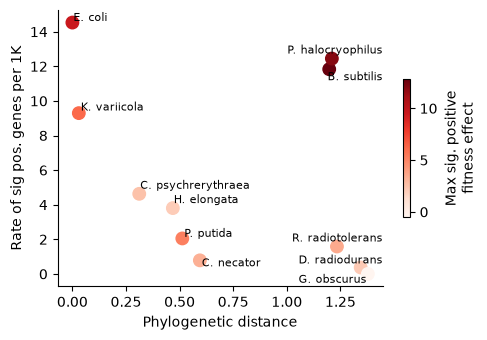

In [43]:
fig, ax = plt.subplots(figsize=(5, 3.5))

sc = ax.scatter(
    per_genome_hit_info["distance_to_ecoli"],
    per_genome_hit_info["hit_rate_per1k"],
    c=per_genome_hit_info["max_magnitude"],
    s=80,
    cmap="Reds",
)
fig.colorbar(sc, ax=ax, label="Max sig. positive\nfitness effect", shrink=0.5, location="right")

texts = [
    ax.text(
        row["distance_to_ecoli"],
        row["hit_rate_per1k"],
        f"{row['species_name'].split()[0][0]}. {row['species_name'].split()[1]}",
        fontsize=8,
    )
    for _, row in per_genome_hit_info.iterrows()
]

ax.set_xlabel("Phylogenetic distance", fontsize=10)
ax.set_ylabel("Rate of sig pos. genes per 1K", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
adjust_text(texts, ax=ax, expand_objects=(1.5, 1.5),)

fig.savefig(RESULTS_DIR / "figure3a_fitness_effects_by_phylo_distance.pdf", bbox_inches="tight")

plt.show()


In [44]:
smf.ols("hit_rate_per1k ~ distance_to_ecoli", data=per_genome_hit_info).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hit_rate_per1k   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.087
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.324
Time:                        21:27:30   Log-Likelihood:                -33.051
No. Observations:                  11   AIC:                             70.10
Df Residuals:                       9   BIC:                             70.90
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             8.0965      2.914      2.778      0.021       1.504      14.689
distance_to_ecoli    -3.3470      3.211     -1.042      0.324     -10.611       3.916
==============================================================================
Omnibus:                        2.528   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.283   Jarque-Bera (JB):                1.617
Skew:                           0.759   Prob(JB):                        0.446
Kurtosis:                       1.893   Cond. No.                         3.29
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

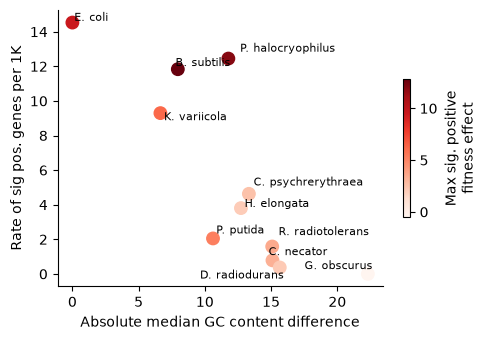

In [46]:
fig, ax = plt.subplots(figsize=(5, 3.5))

sc = ax.scatter(
    per_genome_hit_info["median_gc_diff"],
    per_genome_hit_info["hit_rate_per1k"],
    c=per_genome_hit_info["max_magnitude"],
    s=80,
    cmap="Reds",
)
fig.colorbar(sc, ax=ax, label="Max sig. positive\nfitness effect", shrink=0.5, location="right")

texts = [
    ax.text(
        row["median_gc_diff"],
        row["hit_rate_per1k"],
        f"{row['species_name'].split()[0][0]}. {row['species_name'].split()[1]}",
        fontsize=8,
    )
    for _, row in per_genome_hit_info.iterrows()
]
adjust_text(texts, ax=ax, expand_points=(2, 2), expand_text=(2, 2))

ax.set_xlabel("Absolute median GC content difference", fontsize=10)
ax.set_ylabel("Rate of sig pos. genes per 1K", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

plt.show()

fig.savefig(RESULTS_DIR / "figure3b_fitness_effects_by_gc_distance.pdf", bbox_inches="tight")


In [47]:
smf.ols("hit_rate_per1k ~ median_gc_diff", data=per_genome_hit_info).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hit_rate_per1k   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     18.21
Date:                Tue, 21 Jul 2026   Prob (F-statistic):            0.00209
Time:                        21:27:31   Log-Likelihood:                -27.592
No. Observations:                  11   AIC:                             59.18
Df Residuals:                       9   BIC:                             59.98
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         14.7588      2.369      6.231      0.000       9.400      20.117
median_gc_diff    -0.7699      0.180     -4.268      0.002      -1.178      -0.362
==============================================================================
Omnibus:                        3.016   Durbin-Watson:                   2.337
Prob(Omnibus):                  0.221   Jarque-Bera (JB):                1.184
Skew:                           0.800   Prob(JB):                        0.553
Kurtosis:                       3.159   Cond. No.                         31.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
smf.ols("hit_rate_per1k ~ median_gc_diff + distance_to_ecoli", data=per_genome_hit_info).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hit_rate_per1k   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     11.80
Date:                Tue, 21 Jul 2026   Prob (F-statistic):            0.00411
Time:                        21:27:31   Log-Likelihood:                -26.122
No. Observations:                  11   AIC:                             58.24
Df Residuals:                       8   BIC:                             59.44
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            14.6493      2.199      6.661      0.000       9.578      19.721
median_gc_diff       -0.9987      0.222     -4.494      0.002      -1.511      -0.486
distance_to_ecoli     3.7698      2.408      1.566      0.156      -1.783       9.323
==============================================================================
Omnibus:                        0.040   Durbin-Watson:                   1.899
Prob(Omnibus):                  0.980   Jarque-Bera (JB):                0.240
Skew:                           0.098   Prob(JB):                        0.887
Kurtosis:                       2.303   Cond. No.                         34.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

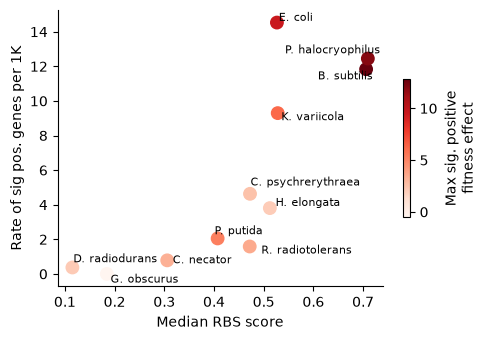

In [49]:
fig, ax = plt.subplots(figsize=(5, 3.5))

sc = ax.scatter(
    per_genome_hit_info["median_RBS_score"],
    per_genome_hit_info["hit_rate_per1k"],
    c=per_genome_hit_info["max_magnitude"],
    s=80,
    cmap="Reds",
)
fig.colorbar(sc, ax=ax, label="Max sig. positive\nfitness effect", shrink=0.5, location="right")

texts = [
    ax.text(
        row["median_RBS_score"],
        row["hit_rate_per1k"],
        f"{row['species_name'].split()[0][0]}. {row['species_name'].split()[1]}",
        fontsize=8,
    )
    for _, row in per_genome_hit_info.iterrows()
]
adjust_text(texts, ax=ax, expand_points=(2, 2), expand_text=(2, 2))

ax.set_xlabel("Median RBS score", fontsize=10)
ax.set_ylabel("Rate of sig pos. genes per 1K", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

fig.savefig(RESULTS_DIR / "figure3c_fitness_effects_by_rbs.pdf", bbox_inches="tight")


In [50]:
smf.ols("hit_rate_per1k ~ median_RBS_score", data=per_genome_hit_info).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hit_rate_per1k   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     16.40
Date:                Tue, 21 Jul 2026   Prob (F-statistic):            0.00289
Time:                        21:27:31   Log-Likelihood:                -27.972
No. Observations:                  11   AIC:                             59.94
Df Residuals:                       9   BIC:                             60.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -4.8049      2.761     -1.740      0.116     -11.051       1.441
median_RBS_score    23.1162      5.708      4.050      0.003      10.204      36.029
==============================================================================
Omnibus:                        3.104   Durbin-Watson:                   1.361
Prob(Omnibus):                  0.212   Jarque-Bera (JB):                1.085
Skew:                           0.754   Prob(JB):                        0.581
Kurtosis:                       3.309   Cond. No.                         6.72
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [51]:
smf.ols("hit_rate_per1k ~ median_RBS_score + distance_to_ecoli", data=per_genome_hit_info).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hit_rate_per1k   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     8.031
Date:                Tue, 21 Jul 2026   Prob (F-statistic):             0.0122
Time:                        21:27:31   Log-Likelihood:                -27.622
No. Observations:                  11   AIC:                             61.24
Df Residuals:                       8   BIC:                             62.44
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -3.1889      3.608     -0.884      0.403     -11.508       5.131
median_RBS_score     22.1139      6.025      3.670      0.006       8.219      36.009
distance_to_ecoli    -1.5487      2.136     -0.725      0.489      -6.474       3.377
==============================================================================
Omnibus:                        0.614   Durbin-Watson:                   1.397
Prob(Omnibus):                  0.736   Jarque-Bera (JB):                0.582
Skew:                           0.418   Prob(JB):                        0.747
Kurtosis:                       2.245   Cond. No.                         8.87
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

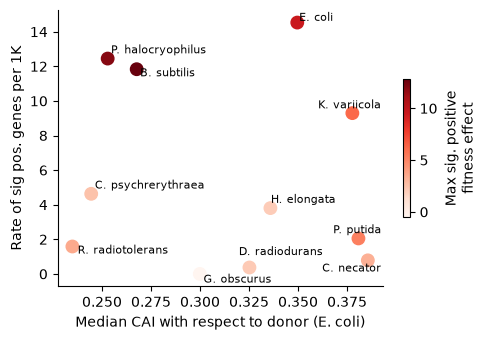

In [52]:
fig, ax = plt.subplots(figsize=(5, 3.5))

sc = ax.scatter(
    per_genome_hit_info["median_CAI"],
    per_genome_hit_info["hit_rate_per1k"],
    c=per_genome_hit_info["max_magnitude"],
    s=80,
    cmap="Reds",
)
fig.colorbar(sc, ax=ax, label="Max sig. positive\nfitness effect", shrink=0.5, location="right")

texts = [
    ax.text(
        row["median_CAI"],
        row["hit_rate_per1k"],
        f"{row['species_name'].split()[0][0]}. {row['species_name'].split()[1]}",
        fontsize=8,
    )
    for _, row in per_genome_hit_info.iterrows()
]
adjust_text(texts, ax=ax, expand_points=(2, 2), expand_text=(2, 2))

ax.set_xlabel("Median CAI with respect to donor (E. coli)", fontsize=10)
ax.set_ylabel("Rate of sig pos. genes per 1K", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

fig.savefig(RESULTS_DIR / "figure3d_fitness_effects_by_cai.pdf", bbox_inches="tight")


In [53]:
smf.ols("hit_rate_per1k ~ median_CAI", data=per_genome_hit_info).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hit_rate_per1k   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.095
Method:                 Least Squares   F-statistic:                    0.1298
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.727
Time:                        21:27:32   Log-Likelihood:                -33.599
No. Observations:                  11   AIC:                             71.20
Df Residuals:                       9   BIC:                             71.99
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.1283     10.005      0.912      0.385     -13.504      31.760
median_CAI   -11.3087     31.386     -0.360      0.727     -82.309      59.691
==============================================================================
Omnibus:                        2.339   Durbin-Watson:                   2.206
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                1.267
Skew:                           0.539   Prob(JB):                        0.531
Kurtosis:                       1.734   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [54]:
smf.ols("hit_rate_per1k ~ median_CAI + distance_to_ecoli", data=per_genome_hit_info).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hit_rate_per1k   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     1.212
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.347
Time:                        21:27:32   Log-Likelihood:                -32.223
No. Observations:                  11   AIC:                             70.45
Df Residuals:                       8   BIC:                             71.64
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.3560     12.829      1.743      0.120      -7.227      51.939
median_CAI          -39.8425     34.938     -1.140      0.287    -120.411      40.726
distance_to_ecoli    -5.6667      3.757     -1.508      0.170     -14.330       2.997
==============================================================================
Omnibus:                        2.026   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.363   Jarque-Bera (JB):                1.164
Skew:                           0.510   Prob(JB):                        0.559
Kurtosis:                       1.775   Cond. No.                         30.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [55]:
smf.ols("hit_rate_per1k ~ median_gc_diff + median_RBS_score", data=per_genome_hit_info).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hit_rate_per1k   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     17.76
Date:                Tue, 21 Jul 2026   Prob (F-statistic):            0.00114
Time:                        21:27:32   Log-Likelihood:                -24.362
No. Observations:                  11   AIC:                             54.72
Df Residuals:                       8   BIC:                             55.92
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            5.1759      4.227      1.224      0.256      -4.573      14.924
median_gc_diff      -0.4911      0.180     -2.724      0.026      -0.907      -0.075
median_RBS_score    13.9352      5.511      2.529      0.035       1.227      26.644
==============================================================================
Omnibus:                        1.041   Durbin-Watson:                   1.884
Prob(Omnibus):                  0.594   Jarque-Bera (JB):                0.661
Skew:                          -0.044   Prob(JB):                        0.719
Kurtosis:                       1.802   Cond. No.                         114.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Per Gene Hit Probability

### Data preparation

We work from `salt_genes_filt` (protein-coding, LB + 4% NaCl, Hit or Not Hit). The `gc_content` column is already present as a percentage (0–100 scale). We also pre-compute binned empirical hit probabilities (3% bins) which will be overlaid on the fitted curve as a visual sanity check.

### Statistical analysis

The empirical binning suggests a non-monotonic (inverted-U) relationship: hit probability is highest in the mid-GC range and drops toward both extremes. A standard logistic regression (sigmoid) would miss this, so we fit a **quadratic logistic regression**:

$$\log\frac{P(\text{Hit})}{1 - P(\text{Hit})} = \beta_0 + \beta_1 \cdot \text{GC} + \beta_2 \cdot \text{GC}^2$$

A significant negative $\beta_2$ confirms the inverted-U shape. We also run a **Mann–Whitney U test** as a non-parametric check that GC content distributions differ between Hits and Not Hits, without assuming any particular functional form.

In [56]:
per_gene_df = (
    salt_genes_filt[["gene_id", "species_name", "gene_call", "gc_content", "CAI_rel_to_Ecoli", "Sapiens_RBS_Score", "lmer_estimate"]]
    .copy()
)
per_gene_df["is_hit"] = ((per_gene_df["gene_call"] == "Hit") & (per_gene_df["lmer_estimate"] > 0)).astype(int)
per_gene_df["gc_content_diff_ecoli"] = per_gene_df["gc_content"] - median_e_coli_gc

per_genome_hit_info["short_name"] = per_genome_hit_info["species_name"].apply(lambda x: f"{x.split()[0][0]}. {x.split()[1]}")
per_genome_hit_info.sort_values("distance_to_ecoli", inplace = True)

per_gene_df["short_name"] = per_gene_df["species_name"].apply(lambda x: f"{x.split()[0][0]}. {x.split()[1]}")

gc_df = per_gene_df.dropna(subset=["gc_content"])
gc_df.head()

,gene_id,species_name,gene_call,gc_content,CAI_rel_to_Ecoli,Sapiens_RBS_Score,lmer_estimate,is_hit,gc_content_diff_ecoli,short_name
2,gene-b0003,Escherichia coli,Not Hit,56.27,0.3503,0.706415,-0.038143,0,4.275,E. coli
4,gene-b0005,Escherichia coli,Not Hit,53.87,0.3662,0.884806,-0.387165,0,1.875,E. coli
5,gene-b0006,Escherichia coli,Not Hit,49.68,0.3607,0.169088,0.223885,0,-2.315,E. coli
6,gene-b0007,Escherichia coli,Not Hit,53.32,0.3240,0.744774,0.648415,0,1.325,E. coli
7,gene-b0008,Escherichia coli,Not Hit,51.99,0.6212,0.571006,0.290096,0,-0.005,E. coli


In [57]:
# --- binned empirical hit probability (3% windows) ---
gc_df["gc_bin"] = pd.cut(gc_df["gc_content"], bins=range(0, 100, 3))
bins = (
    gc_df.groupby("gc_bin", observed=True)
    .agg(n_genes=("gene_id", "count"), n_hits=("is_hit", "sum"))
    .assign(
        bin_mid=lambda d: d.index.map(lambda iv: iv.mid),
        p_hit=lambda d: d["n_hits"] / d["n_genes"],
    )
    .reset_index(drop=True)
    .query("n_genes >= 20")   # drop bins with very few genes
)

gc_df["sig"] = gc_df["is_hit"].apply(lambda x: "Sig. gene" if x == 1 else "Non-sig. gene")

print(f"Genes with GC content: {len(gc_df):,}")
print(f"  Hits:    {gc_df['is_hit'].sum():,}  ({gc_df['is_hit'].mean():.3%})")
print(f"  Not Hit: {(gc_df['is_hit'] == 0).sum():,}")
print(f"GC range: {gc_df['gc_content'].min():.1f}–{gc_df['gc_content'].max():.1f}%")
print(f"\n{len(bins)} bins retained after n_genes ≥ 20 filter")

Genes with GC content: 38,865
  Hits:    200  (0.515%)
  Not Hit: 38,665
GC range: 13.6–85.5%

19 bins retained after n_genes ≥ 20 filter


In [59]:
from scipy.stats import mannwhitneyu

# --- quadratic logistic regression ---
model_gc = smf.logit("is_hit ~ gc_content + I(gc_content**2)", data=gc_df).fit()
print(model_gc.summary())

# --- Mann–Whitney U: are GC distributions different between Hits and Not Hits? ---
hits_gc    = gc_df.loc[gc_df["is_hit"] == 1, "gc_content"]
nothits_gc = gc_df.loc[gc_df["is_hit"] == 0, "gc_content"]
mwu_stat, mwu_p = mannwhitneyu(hits_gc, nothits_gc, alternative="two-sided")

print(f"\nMann–Whitney U:  stat = {mwu_stat:.0f},  p = {mwu_p:.3g}")
print(f"Median GC — Hits: {hits_gc.median():.1f}%,  Not Hit: {nothits_gc.median():.1f}%")

Optimization terminated successfully.
         Current function value: 0.029845
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                 is_hit   No. Observations:                38865
Model:                          Logit   Df Residuals:                    38862
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                 0.07457
Time:                        21:27:32   Log-Likelihood:                -1159.9
converged:                       True   LL-Null:                       -1253.4
Covariance Type:            nonrobust   LLR p-value:                 2.557e-41
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -23.2547      2.406     -9.667      0.000     -27.970     -18.540
gc_c

In [60]:
# --- quadratic logistic regression ---
model_gc_species = smf.logit("is_hit ~ species_name + gc_content + I(gc_content**2)", data=gc_df).fit()
print(model_gc_species.summary())

         Current function value: 0.029382
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 is_hit   No. Observations:                38865
Model:                          Logit   Df Residuals:                    38852
Method:                           MLE   Df Model:                           12
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                 0.08894
Time:                        21:27:33   Log-Likelihood:                -1141.9
converged:                      False   LL-Null:                       -1253.4
Covariance Type:            nonrobust   LLR p-value:                 5.807e-41
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                    -18.7135      3.338     -5.606     

/opt/tljh/user/envs/ppat-019/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Visualization

Two-panel figure:
- **Top**: fitted quadratic logistic curve with 95% confidence interval, overlaid on the empirical binned hit probabilities. Each point represents a 3% GC bin; marker area is proportional to the number of genes in that bin. The dashed horizontal line shows the baseline (overall) hit rate.
- **Bottom**: kernel density estimate of GC content separately for Hits and Not Hits, showing where each category is concentrated across the GC spectrum.

In [61]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- fitted curve over observed GC range ---
gc_range = np.linspace(gc_df["gc_content"].min(), gc_df["gc_content"].max(), 400)
pred_df  = pd.DataFrame({"gc_content": gc_range})
pred     = model_gc.get_prediction(pred_df)
pred_mean = pred.predicted
pred_ci   = pred.conf_int(alpha=0.05)   # shape (n, 2): [:, 0] lower, [:, 1] upper
baseline = gc_df["is_hit"].mean()


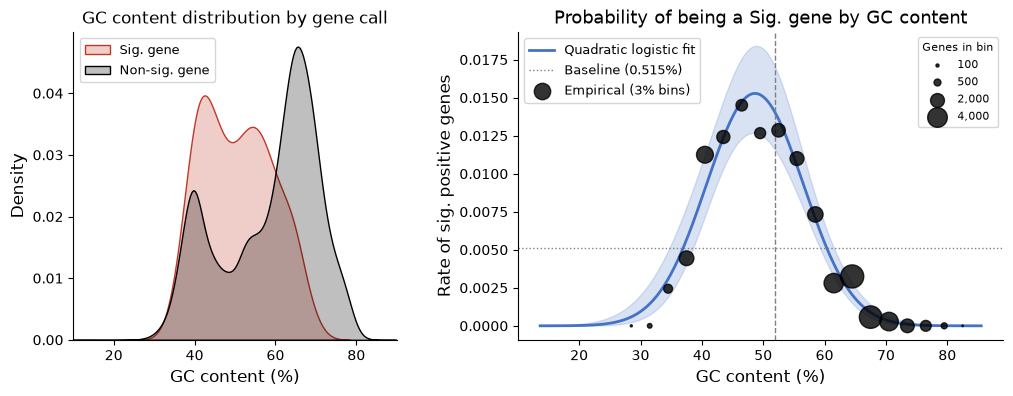

In [62]:
fig, axes = plt.subplots(
    1, 2, figsize=(12, 4),
    gridspec_kw={"width_ratios": [1, 1.5], "wspace": 0.3},
)


# ── Panel 1: marginal KDE ────────────────────────────────────────────────────
ax = axes[0]
for call, color in [("Sig. gene", "#C0392B"), ("Non-sig. gene", "black")]:
    sub = gc_df[gc_df["sig"] == call]["gc_content"]
    sns.kdeplot(sub, ax=ax, color=color, fill=True, alpha=0.25, label=call)

ax.set_xlabel("GC content (%)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("GC content distribution by gene call", fontsize=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(10, 90)

# ── Panel 2: probability curve ───────────────────────────────────────────────
ax2 = axes[1]

ax2.fill_between(gc_range, pred_ci[:, 0], pred_ci[:, 1],
                alpha=0.2, color="#4472C4")
ax2.plot(gc_range, pred_mean, color="#4472C4", linewidth=2,
        label="Quadratic logistic fit")
ax2.axhline(baseline, color="gray", linestyle=":", linewidth=1,
           label=f"Baseline ({baseline:.3%})")

# Binned empirical probabilities — marker size ∝ n_genes
ax2.scatter(
    bins["bin_mid"], bins["p_hit"],
    s=bins["n_genes"] / 20,
    color="black", zorder=5, alpha=0.8,
    label="Empirical (3% bins)",
)

# Curve/line legend — upper left
legend1 = ax2.legend(fontsize=9, loc="upper left")
ax2.add_artist(legend1)

# Size legend — upper right
size_handles = [
    ax2.scatter([], [], s=n / 20, color="black", alpha=0.8, label=f"{n:,}")
    for n in [100, 500, 2000, 4000]
]
ax2.legend(
    handles=size_handles,
    title="Genes in bin",
    title_fontsize=8,
    fontsize=8,
    loc="upper right",
)

ax2.set_xlabel("GC content (%)", fontsize=12)
ax2.set_ylabel("Rate of sig. positive genes", fontsize=12)
ax2.set_title("Probability of being a Sig. gene by GC content", fontsize=13)
ax2.axvline(x=median_e_coli_gc, color="gray", linestyle="--", linewidth=1, label="Median E. coli GC content")
ax2.spines[["top", "right"]].set_visible(False)
#ax2.set_xlim(10, 90)

fig.savefig(RESULTS_DIR / "figure3e_gc_content_vs_hit_probability.pdf", bbox_inches="tight")
plt.show()


# RBS Binding vs Hit Probability

In [67]:
rbs_df = per_gene_df.dropna(subset=["Sapiens_RBS_Score"]).copy()

# --- binned empirical hit probability (0.02-unit windows) ---
rbs_bin_edges = np.arange(0.0, 1.0, 0.05)
rbs_df["rbs_bin"] = pd.cut(rbs_df["Sapiens_RBS_Score"], bins=rbs_bin_edges)
rbs_bins = (
    rbs_df.groupby("rbs_bin", observed=True)
    .agg(n_genes=("gene_id", "count"), n_hits=("is_hit", "sum"))
    .assign(
        bin_mid=lambda d: d.index.map(lambda iv: iv.mid),
        p_hit=lambda d: d["n_hits"] / d["n_genes"],
    )
    .reset_index(drop=True)
    .query("n_genes >= 20")
)

# --- linear logistic regression ---
model_rbs = smf.logit("is_hit ~ Sapiens_RBS_Score", data=rbs_df).fit()
print(model_rbs.summary())

# --- Mann–Whitney U ---
hits_rbs    = rbs_df.loc[rbs_df["is_hit"] == 1, "Sapiens_RBS_Score"]
nothits_rbs = rbs_df.loc[rbs_df["is_hit"] == 0, "Sapiens_RBS_Score"]
mwu_stat_rbs, mwu_p_rbs = mannwhitneyu(hits_rbs, nothits_rbs, alternative="two-sided")
print(f"\nMann–Whitney U:  stat = {mwu_stat_rbs:.0f},  p = {mwu_p_rbs:.3g}")
print(f"Median RBS — Hits: {hits_rbs.median():.4f},  Not Hit: {nothits_rbs.median():.4f}")

# --- predictions over observed CAI range ---
rbs_range  = np.linspace(rbs_df["Sapiens_RBS_Score"].min(), rbs_df["Sapiens_RBS_Score"].max(), 400)
pred_rbs   = model_rbs.get_prediction(pd.DataFrame({"Sapiens_RBS_Score": rbs_range}))
pred_rbs_mean = pred_rbs.predicted
pred_rbs_ci   = pred_rbs.conf_int(alpha=0.05)

Optimization terminated successfully.
         Current function value: 0.031730
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 is_hit   No. Observations:                38864
Model:                          Logit   Df Residuals:                    38862
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                 0.01614
Time:                        21:28:25   Log-Likelihood:                -1233.2
converged:                       True   LL-Null:                       -1253.4
Covariance Type:            nonrobust   LLR p-value:                 2.011e-10
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -6.1027      0.170    -35.965      0.000      -6.435      -5.770
Sapiens

/tmp/ipykernel_3543368/1717004900.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


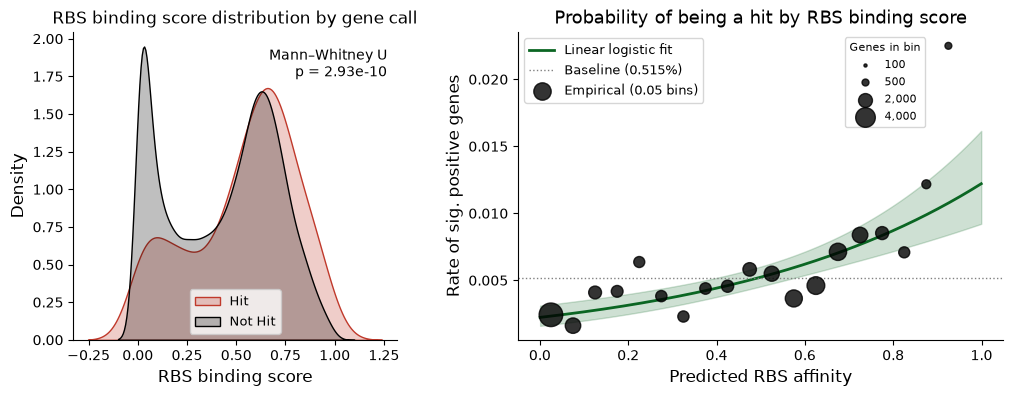

In [68]:
fig, axes = plt.subplots(
    1, 2, figsize=(12, 4),
    gridspec_kw={"width_ratios": [1, 1.5], "wspace": 0.3},
)

# ── Panel 1: KDE of CAI for hits vs. non-hits ────────────────────────────────
ax_kde = axes[0]
for call, color in [("Hit", "#C0392B"), ("Not Hit", "black")]:
    sub = rbs_df[rbs_df["gene_call"] == call]["Sapiens_RBS_Score"]
    sns.kdeplot(sub, ax=ax_kde, color=color, fill=True, alpha=0.25, label=call)

ax_kde.set_xlabel("RBS binding score", fontsize=12)
ax_kde.set_ylabel("Density", fontsize=12)
ax_kde.set_title("RBS binding score distribution by gene call", fontsize=12)
ax_kde.legend(fontsize=9)
ax_kde.text(
    0.97, 0.95, f"Mann–Whitney U\np = {mwu_p_rbs:.3g}",
    transform=ax_kde.transAxes, ha="right", va="top", fontsize=10,
)
ax_kde.spines[["top", "right"]].set_visible(False)

# ── Panel 2: logistic regression probability curve + binned scatter ───────────
ax_lr = axes[1]
baseline_rbs = rbs_df["is_hit"].mean()

ax_lr.fill_between(
    rbs_range, pred_rbs_ci[:, 0], pred_rbs_ci[:, 1],
    color="#0B6623", alpha=0.20,
)
ax_lr.plot(
    rbs_range, pred_rbs_mean,
    color="#0B6623", linewidth=2, label="Linear logistic fit",
)
ax_lr.axhline(baseline_rbs, color="gray", linestyle=":", linewidth=1,
              label=f"Baseline ({baseline_rbs:.3%})")

ax_lr.scatter(
    rbs_bins["bin_mid"], rbs_bins["p_hit"],
    s=rbs_bins["n_genes"] / 20,
    color="black", zorder=4, alpha=0.8,
    label="Empirical (0.05 bins)",
)

# curve legend — upper left
legend1 = ax_lr.legend(fontsize=9, loc="upper left")
ax_lr.add_artist(legend1)

# size legend — upper right
size_handles = [
    ax_lr.scatter([], [], s=n / 20, color="black", alpha=0.8, label=f"{n:,}")
    for n in [100, 500, 2000, 4000]
]
ax_lr.legend(
    handles=size_handles,
    title="Genes in bin", title_fontsize=8,
    fontsize=8, loc="upper right", bbox_to_anchor=(0.85, 1.0),
)

ax_lr.set_xlabel("Predicted RBS affinity", fontsize=12)
ax_lr.set_ylabel("Rate of sig. positive genes", fontsize=12)
ax_lr.set_title("Probability of being a hit by RBS binding score", fontsize=13)
ax_lr.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

fig.savefig(RESULTS_DIR / "figure3f_rbs_vs_hit_probability.pdf", bbox_inches="tight")


In [71]:
model_two_var = smf.logit("is_hit ~ Sapiens_RBS_Score + gc_content + I(gc_content**2)", data=per_gene_df).fit()
print(model_two_var.summary())

Optimization terminated successfully.
         Current function value: 0.029756
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                 is_hit   No. Observations:                38864
Model:                          Logit   Df Residuals:                    38860
Method:                           MLE   Df Model:                            3
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                 0.07734
Time:                        21:28:28   Log-Likelihood:                -1156.4
converged:                       True   LL-Null:                       -1253.4
Covariance Type:            nonrobust   LLR p-value:                 8.886e-42
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -23.3760      2.424     -9.645      0.000     -28.126     -18.626
Sapi

In [72]:
stats.chi2.sf(-2* (model_gc.llf - model_two_var.llf), 1)

np.float64(0.008380736099052077)

In [73]:
model_three_var = smf.logit("is_hit ~ Sapiens_RBS_Score + gc_content_diff_ecoli + I(gc_content_diff_ecoli**2) + CAI_rel_to_Ecoli", data=per_gene_df).fit()
print(model_three_var.summary())

Optimization terminated successfully.
         Current function value: 0.029689
         Iterations 11


                           Logit Regression Results                           
Dep. Variable:                 is_hit   No. Observations:                38864
Model:                          Logit   Df Residuals:                    38859
Method:                           MLE   Df Model:                            4
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                 0.07943
Time:                        21:28:28   Log-Likelihood:                -1153.8
converged:                       True   LL-Null:                       -1253.4
Covariance Type:            nonrobust   LLR p-value:                 5.807e-42
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -5.3230      0.344    -15.473      0.000      -5.997      -4.649
Sapiens_RBS_Score                 0.7257      0.297      2.441      0.015 

In [74]:
stats.chi2.sf(-2* (model_two_var.llf - model_three_var.llf), 1)

np.float64(0.02198988001019413)